In [5]:
#load the complete volume of the image.

import os
import numpy as np
import random
import nibabel as nib
import tensorflow as tf
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
from scipy.ndimage import zoom


# Load NIfTI file and convert to NumPy array
def load_nii(path, is_mask=False):
    nii = nib.load(path)
    arr = np.array(nii.get_fdata(), dtype=np.float32)  # Convert to float32
    if is_mask:
        arr = arr.astype(np.int32)  # Masks as integers
    return arr


# Data Generator
def imageLoader_full(root_dir, patient_list, batch_size):

    L = len(patient_list)
    indices = np.arange(L)

    while True:
        indices = shuffle(indices, random_state=None)

        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)
            batch_indices = indices[batch_start:limit]

            X_t1c, X_t1n, X_t2f, X_t2w, Y = [], [], [], [], []

            for i in batch_indices:
                patient_id = patient_list[i]
                patient_path = os.path.join(root_dir, patient_id)

                files_needed = [
                    f"{patient_id}-t1n.nii",
                    f"{patient_id}-t1c.nii",
                    f"{patient_id}-t2w.nii",
                    f"{patient_id}-t2f.nii",
                    f"{patient_id}-seg.nii"
                ]

                files_exist = all(os.path.exists(os.path.join(patient_path, f)) for f in files_needed)
                if not files_exist:
                    print(f"Skipping {patient_id} due to missing files.")
                    continue

                # --> ADDED TRY-EXCEPT BLOCK HERE <--
                try:
                    # Load and resize modalities
                    t1c = load_nii(os.path.join(patient_path, f"{patient_id}-t1c.nii"))
                    t1n = load_nii(os.path.join(patient_path, f"{patient_id}-t1n.nii"))
                    t2f = load_nii(os.path.join(patient_path, f"{patient_id}-t2f.nii"))
                    t2w = load_nii(os.path.join(patient_path, f"{patient_id}-t2w.nii"))
                    mask = load_nii(os.path.join(patient_path, f"{patient_id}-seg.nii"), is_mask=True)
                except OSError as e:
                    print(f"Skipping {patient_id} due to corrupted file (OSError): {e}")
                    continue
                except Exception as e:
                    print(f"Skipping {patient_id} due to unexpected error: {e}")
                    continue

                # Append to batch (only runs if the try block above succeeds)
                X_t1c.append(t1c)
                X_t1n.append(t1n)
                X_t2f.append(t2f)
                X_t2w.append(t2w)
                Y.append(mask)

            # If all files in this batch were corrupted or missing, skip yielding and move to next batch
            if len(X_t1n) == 0:
                batch_start += batch_size
                batch_end += batch_size
                continue

            # Convert lists to NumPy arrays explicitly
            X_t1c = np.array(X_t1c, dtype=np.float32)
            X_t1n = np.array(X_t1n, dtype=np.float32)
            X_t2f = np.array(X_t2f, dtype=np.float32)
            X_t2w = np.array(X_t2w, dtype=np.float32)
            Y = np.array(Y, dtype=np.int32)

            # Normalization
            X_t1c = (X_t1c - np.mean(X_t1c)) / (np.std(X_t1c) + 1e-8) # Added tiny epsilon to prevent division by zero
            X_t1n = (X_t1n - np.mean(X_t1n)) / (np.std(X_t1n) + 1e-8)
            X_t2f = (X_t2f - np.mean(X_t2f)) / (np.std(X_t2f) + 1e-8)
            X_t2w = (X_t2w - np.mean(X_t2w)) / (np.std(X_t2w) + 1e-8)

            # Stack modalities
            X = np.stack([X_t1c, X_t1n, X_t2f, X_t2w], axis=4)

            Y = to_categorical(Y, num_classes=5)

            yield (X, Y)

            batch_start += batch_size
            batch_end += batch_size


# Paths & Dataset
root_dir_full = r"F:\BraTs 2024 Data Unpatched Complete Data\Training"
patient_list_full = sorted(os.listdir(root_dir_full))

batch_size_full = 1

train_img_full = imageLoader_full(
    root_dir=root_dir_full,
    patient_list=patient_list_full,
    batch_size=batch_size_full,
)

img_full, msk_full = train_img_full.__next__()
test_img_full = img_full[0]
test_mask_full = msk_full[0]

print("Image shape:", test_img_full.shape)
print("Mask shape:", test_mask_full.shape)

Image shape: (128, 128, 128, 4)
Mask shape: (128, 128, 128, 5)


In [3]:
# BraTS 2024 Data Loader (Skip Folder if Any File Empty)

import os
import numpy as np
import nibabel as nib
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical


# Validate Patient Folder
def is_valid_patient(patient_path, patient_id):

    files = [
        f"{patient_id}-t1n.nii",
        f"{patient_id}-t1c.nii",
        f"{patient_id}-t2w.nii",
        f"{patient_id}-t2f.nii",
        f"{patient_id}-seg.nii"
    ]

    for f in files:

        file_path = os.path.join(patient_path, f)

        if not os.path.exists(file_path):
            print(f"❌ Missing file → Skipping folder: {patient_id}")
            return False

        if os.path.getsize(file_path) == 0:
            print(f"❌ Empty file ({f}) → Skipping folder: {patient_id}")
            return False

    return True


# Load NIfTI
def load_nii(path, is_mask=False):

    nii = nib.load(path)
    arr = np.array(nii.get_fdata(), dtype=np.float32)

    if is_mask:
        arr = arr.astype(np.int32)

    return arr



# Brain Bounding Box
def get_brain_bbox(volume, margin=8):

    non_zero = np.argwhere(volume > 0)

    if len(non_zero) == 0:
        return (0, volume.shape[0],
                0, volume.shape[1],
                0, volume.shape[2])

    min_coords = non_zero.min(axis=0)
    max_coords = non_zero.max(axis=0)

    min_coords = np.maximum(min_coords - margin, 0)
    max_coords = np.minimum(max_coords + margin, np.array(volume.shape) - 1)

    return (min_coords[0], max_coords[0] + 1,
            min_coords[1], max_coords[1] + 1,
            min_coords[2], max_coords[2] + 1)


# Crop with bounding box
def crop_with_bbox(volume, bbox):
    d1, d2, h1, h2, w1, w2 = bbox
    return volume[d1:d2, h1:h2, w1:w2]


# Final Center Crop
def final_safe_crop(volume, target_shape=(128, 128, 128)):

    td, th, tw = target_shape
    d, h, w = volume.shape

    if d > td:
        start = (d - td) // 2
        volume = volume[start:start + td]
    elif d < td:
        pad = td - d
        volume = np.pad(volume,
                        ((pad//2, pad-pad//2), (0,0), (0,0)),
                        mode='constant')

    d, h, w = volume.shape

    if h > th:
        start = (h - th) // 2
        volume = volume[:, start:start + th, :]
    elif h < th:
        pad = th - h
        volume = np.pad(volume,
                        ((0,0), (pad//2, pad-pad//2), (0,0)),
                        mode='constant')

    d, h, w = volume.shape

    if w > tw:
        start = (w - tw) // 2
        volume = volume[:, :, start:start + tw]
    elif w < tw:
        pad = tw - w
        volume = np.pad(volume,
                        ((0,0), (0,0), (pad//2, pad-pad//2)),
                        mode='constant')

    return volume


# SAFE BATCH GENERATOR
def batch_generator(root_dir, patient_list, batch_size):

    L = len(patient_list)
    indices = np.arange(L)

    while True:

        indices = shuffle(indices)

        for start in range(0, L, batch_size):

            batch_indices = indices[start:start + batch_size]

            X_batch = []
            Y_batch = []

            for i in batch_indices:

                patient_id = patient_list[i]
                patient_path = os.path.join(root_dir, patient_id)


                # Skip folder if any file missing or empty
                if not is_valid_patient(patient_path, patient_id):
                    continue

                try:

                    t1n = load_nii(os.path.join(patient_path, f"{patient_id}-t1n.nii"))
                    t1c = load_nii(os.path.join(patient_path, f"{patient_id}-t1c.nii"))
                    t2w = load_nii(os.path.join(patient_path, f"{patient_id}-t2w.nii"))
                    t2f = load_nii(os.path.join(patient_path, f"{patient_id}-t2f.nii"))
                    mask = load_nii(os.path.join(patient_path, f"{patient_id}-seg.nii"), is_mask=True)

                    bbox = get_brain_bbox(t2f)

                    t1n = final_safe_crop(crop_with_bbox(t1n, bbox))
                    t1c = final_safe_crop(crop_with_bbox(t1c, bbox))
                    t2w = final_safe_crop(crop_with_bbox(t2w, bbox))
                    t2f = final_safe_crop(crop_with_bbox(t2f, bbox))
                    mask = final_safe_crop(crop_with_bbox(mask, bbox))

                    # Normalize
                    t1n = (t1n - np.mean(t1n)) / (np.std(t1n) + 1e-8)
                    t1c = (t1c - np.mean(t1c)) / (np.std(t1c) + 1e-8)
                    t2w = (t2w - np.mean(t2w)) / (np.std(t2w) + 1e-8)
                    t2f = (t2f - np.mean(t2f)) / (np.std(t2f) + 1e-8)

                    X = np.stack([t1n, t1c, t2w, t2f], axis=-1)

                    mask = to_categorical(mask, num_classes=5)

                    X_batch.append(X)
                    Y_batch.append(mask)

                except Exception as e:

                    print(f"⚠ Corrupted folder skipped: {patient_id}")
                    print(e)
                    continue

            if len(X_batch) == 0:
                continue

            yield np.array(X_batch, dtype=np.float32), \
                  np.array(Y_batch, dtype=np.float32)


# Example Usage

root_dir = r"F:\BraTs 2024 Data Unpatched Complete Data\Training"
patient_list = sorted(os.listdir(root_dir))

train_gen = batch_generator(root_dir, patient_list, batch_size=2)

img, msk = next(train_gen)

print("Batch image shape:", img.shape)
print("Batch mask shape:", msk.shape)

Batch image shape: (2, 128, 128, 128, 4)
Batch mask shape: (2, 128, 128, 128, 5)


In [6]:
import numpy as np
import gc
import json
import os
from datetime import datetime


# Dataset root
root_dir = r"F:\BraTs 2024 Data Unpatched Complete Data\Training"  # your single root folder

# Get all patient folders
all_patients = sorted(os.listdir(root_dir))


#  CONFIGURATION  — only change this block between runs
run_name   = "tumor_centered_patch"          # change to "patched" for second run
log_dir    = r"C:\Users\Wahaj Sajid\Desktop\Final-Year-Project\Code\Data Files Extraction\logs"              # folder where JSON logs are saved


# Class definitions
n_classes   = 5
class_names = ["Background", "ET", "NETC", "SNFH", "RC"]

# Region definitions  (index into class_names)
REGIONS = {
    "Background"  : [0],
    "ET"          : [1],
    "RC"          : [4],
    "Tumor Core"  : [1, 2],          # ET + NETC
    "Whole Tumor" : [1, 2, 3],       # ET + NETC + SNFH
}

# Ensure log directory exists
os.makedirs(log_dir, exist_ok=True)
log_path = os.path.join(log_dir, f"log_{run_name}.json")

# Settings
batch_size = 1
num_val    = len(all_patients)
steps      = int(np.ceil(num_val / batch_size))

# Initialize generator
val_gen = batch_generator(root_dir, all_patients, batch_size=batch_size)

# Initialize GT voxel counts  (per class)
gt_voxel_counts = np.zeros(n_classes, dtype=np.int64)


# Process batch by batch
print(f"\n[INFO] Starting voxel count  |  run = '{run_name}'  |  batches = {steps}")
print("=" * 60)

for step in range(steps):
    _, Y_batch = next(val_gen)

    # one-hot → class indices
    Y_true_labels = np.argmax(Y_batch, axis=-1)

    # accumulate per-class counts
    for c in range(n_classes):
        gt_voxel_counts[c] += np.sum(Y_true_labels == c)

    del Y_batch, Y_true_labels
    gc.collect()

    if (step + 1) % 5 == 0 or (step + 1) == steps:
        print(f"  Processed {step + 1}/{steps} batches")

# Compute totals
total_voxels = int(gt_voxel_counts.sum())

# per-class dict
class_counts = {class_names[c]: int(gt_voxel_counts[c]) for c in range(n_classes)}

# region counts  (sum of constituent classes)
region_counts = {}
for region, indices in REGIONS.items():
    region_counts[region] = int(sum(gt_voxel_counts[i] for i in indices))

# percentages
class_pct  = {k: round(v / total_voxels * 100, 4) for k, v in class_counts.items()}
region_pct = {k: round(v / total_voxels * 100, 4) for k, v in region_counts.items()}


# Console output
print(f"\n{'=' * 60}")
print(f"  RUN : {run_name.upper()}   |   Total voxels : {total_voxels:,}")
print(f"{'=' * 60}")

print("\n--- Individual Classes ---")
for c in range(n_classes):
    name = class_names[c]
    print(f"  {name:<12} (class {c}):  {class_counts[name]:>15,}  "
          f"({class_pct[name]:.4f} %)")

print("\n--- Grouped Regions ---")
for region in REGIONS:
    print(f"  {region:<14}:  {region_counts[region]:>15,}  "
          f"({region_pct[region]:.4f} %)")


# Save to JSON log
log_data = {
    "run_name"      : run_name,
    "timestamp"     : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_voxels"  : total_voxels,
    "num_patients"  : len(all_patients),
    "class_counts"  : class_counts,
    "class_pct"     : class_pct,
    "region_counts" : region_counts,
    "region_pct"    : region_pct,
}

with open(log_path, "w") as f:
    json.dump(log_data, f, indent=4)

print(f"\n[INFO] Log saved  →  {log_path}")
print("=" * 60)


[INFO] Starting voxel count  |  run = 'tumor_centered_patch'  |  batches = 904
  Processed 5/904 batches
  Processed 10/904 batches
  Processed 15/904 batches
  Processed 20/904 batches
  Processed 25/904 batches
  Processed 30/904 batches
  Processed 35/904 batches
  Processed 40/904 batches
  Processed 45/904 batches
  Processed 50/904 batches
  Processed 55/904 batches
  Processed 60/904 batches
  Processed 65/904 batches
  Processed 70/904 batches
  Processed 75/904 batches
  Processed 80/904 batches
  Processed 85/904 batches
  Processed 90/904 batches
  Processed 95/904 batches
  Processed 100/904 batches
  Processed 105/904 batches
  Processed 110/904 batches
  Processed 115/904 batches
  Processed 120/904 batches
  Processed 125/904 batches
  Processed 130/904 batches
  Processed 135/904 batches
  Processed 140/904 batches
  Processed 145/904 batches
  Processed 150/904 batches
  Processed 155/904 batches
  Processed 160/904 batches
  Processed 165/904 batches
  Processed 170/

# 2 files comaprison 
1) Simple Centered Cropped
2) Tumor Centered Cropped


[INFO] Chart saved  →  C:\Users\Wahaj Sajid\Desktop\Final-Year-Project\Code\Data Files Extraction\logs\comparison_chart.png


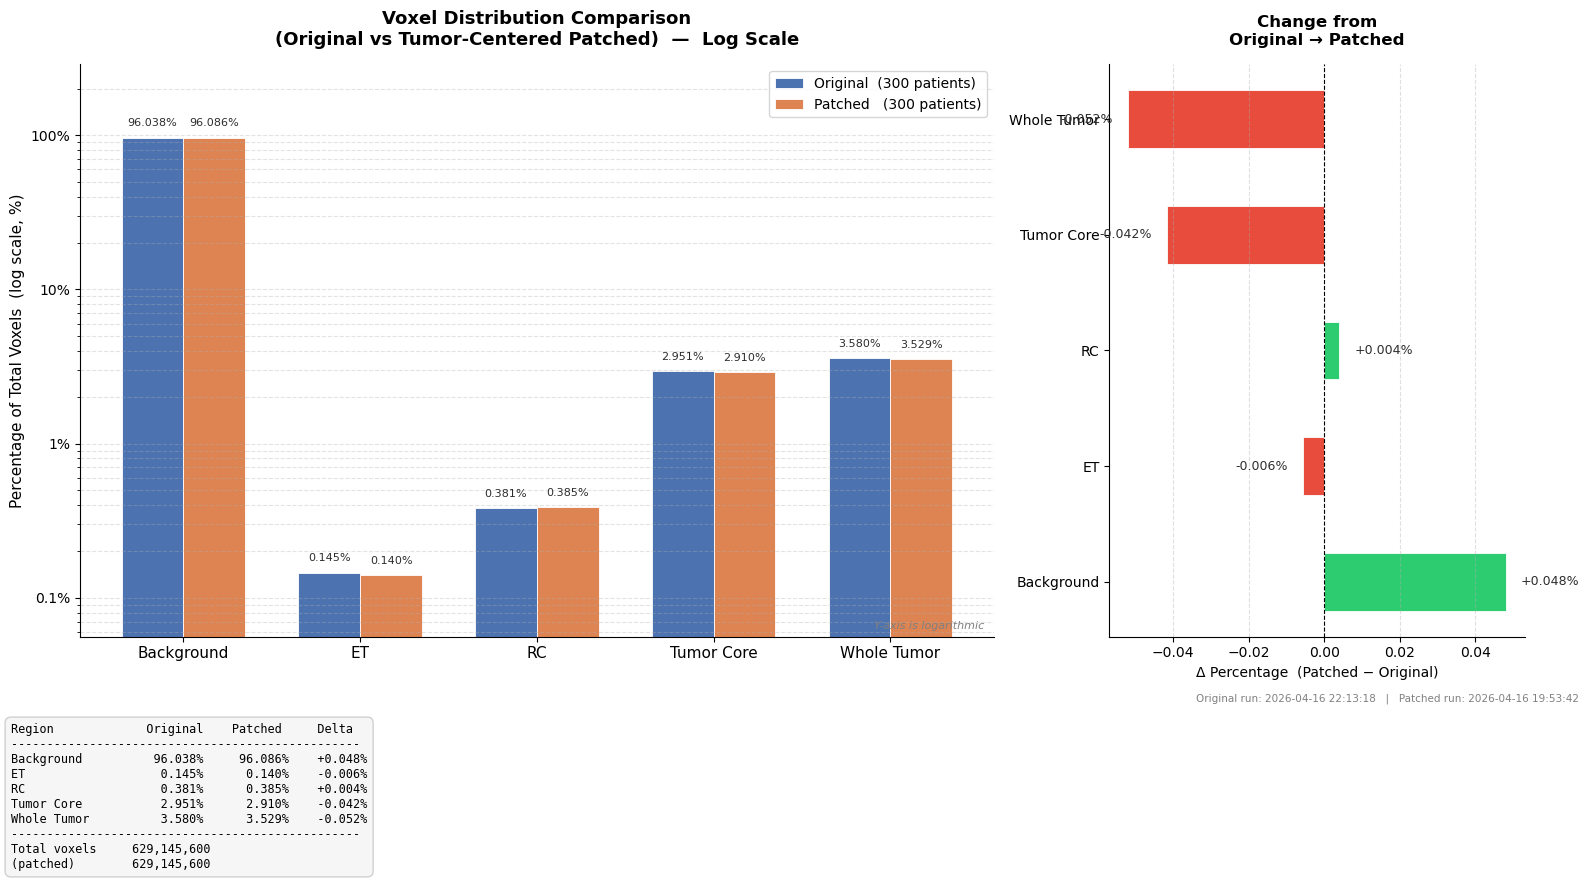


  Region            Original   Patched    Delta
  ------------------------------------------------------
  Background         96.038%    96.086%  ▲ 0.048%
  ET                  0.145%     0.140%  ▼ 0.006%
  RC                  0.381%     0.385%  ▲ 0.004%
  Tumor Core          2.951%     2.910%  ▼ 0.042%
  Whole Tumor         3.580%     3.529%  ▼ 0.052%


In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


#  CONFIGURATION
log_dir      = r"C:\Users\Wahaj Sajid\Desktop\Final-Year-Project\Code\Data Files Extraction\logs"
log_original = os.path.join(log_dir, "log_original.json")
log_patched  = os.path.join(log_dir, "log_simple_centered.json")
output_plot  = os.path.join(log_dir, "comparison_chart.png")

COMPARE_REGIONS = ["Background", "ET", "RC", "Tumor Core", "Whole Tumor"]




# Load logs
def load_log(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Log file not found: {path}\n"
                                f"Run voxel_counter.py first with the matching run_name.")
    with open(path) as f:
        return json.load(f)


orig    = load_log(log_original)
patched = load_log(log_patched)

orig_pct    = [orig["region_pct"][r]    for r in COMPARE_REGIONS]
patched_pct = [patched["region_pct"][r] for r in COMPARE_REGIONS]



# Layout
x     = np.arange(len(COMPARE_REGIONS))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={"width_ratios": [2.2, 1]})

# LEFT — grouped bar chart (LOG SCALE)
ax = axes[0]

bars_orig    = ax.bar(x - width/2, orig_pct,    width,
                      label=f"Original  ({orig['num_patients']} patients)",
                      color="#4C72B0", edgecolor="white", linewidth=0.6)
bars_patched = ax.bar(x + width/2, patched_pct, width,
                      label=f"Patched   ({patched['num_patients']} patients)",
                      color="#DD8452", edgecolor="white", linewidth=0.6)

# Switch to log scale AFTER drawing bars
ax.set_yscale("log")

# Value labels — multiplicative offset works correctly on log scale
def label_bars(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h * 1.15,
            f"{h:.3f}%",
            ha="center", va="bottom",
            fontsize=8, color="#2c2c2c"
        )

label_bars(bars_orig)
label_bars(bars_patched)

# Y-axis: log ticks formatted as percentages
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f"{val:.3g}%")
)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Sensible y limits on log scale
min_val = min(v for v in orig_pct + patched_pct if v > 0)
max_val = max(orig_pct + patched_pct)
ax.set_ylim(min_val * 0.4, max_val * 3)

ax.set_xticks(x)
ax.set_xticklabels(COMPARE_REGIONS, fontsize=11)
ax.set_ylabel("Percentage of Total Voxels  (log scale, %)", fontsize=11)
ax.set_title("Voxel Distribution Comparison\n(Simple Centered Patched vs Tumor-Centered Patched)  —  Log Scale",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=10)
ax.grid(axis="y", which="both", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

# Log-scale annotation
ax.text(0.99, 0.01, "Y-axis is logarithmic",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8, color="gray", style="italic")

# RIGHT — delta chart (linear, unchanged)
ax2 = axes[1]

deltas = [p - o for o, p in zip(orig_pct, patched_pct)]
colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in deltas]

bars_d = ax2.barh(COMPARE_REGIONS, deltas, color=colors,
                  edgecolor="white", linewidth=0.6, height=0.5)

for bar, d in zip(bars_d, deltas):
    xpos = d + (0.004 if d >= 0 else -0.004)
    ha   = "left" if d >= 0 else "right"
    ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
             f"{d:+.3f}%", va="center", ha=ha, fontsize=9, color="#2c2c2c")

ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Δ Percentage  (Patched − Original)", fontsize=10)
ax2.set_title("Change from\nOriginal → Patched", fontsize=12,
              fontweight="bold", pad=14)
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)


# Summary text box
summary_lines = [
    f"{'Region':<16} {'Original':>10} {'Patched':>10} {'Delta':>9}",
    "-" * 49,
]
for r, o, p, d in zip(COMPARE_REGIONS, orig_pct, patched_pct, deltas):
    summary_lines.append(f"{r:<16} {o:>9.3f}%  {p:>9.3f}%  {d:>+8.3f}%")

summary_lines += [
    "-" * 49,
    f"{'Total voxels':<16} {orig['total_voxels']:>10,}",
    f"{'(patched)':<16} {patched['total_voxels']:>10,}",
]

fig.text(0.01, -0.04, "\n".join(summary_lines),
         fontsize=8.5, family="monospace",
         verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5",
                   edgecolor="#cccccc", alpha=0.9))

# Metadata footer
fig.text(0.99, -0.01,
         f"Original run: {orig['timestamp']}   |   "
         f"Patched run: {patched['timestamp']}",
         ha="right", fontsize=7.5, color="gray")

plt.tight_layout()
plt.savefig(output_plot, dpi=150, bbox_inches="tight")
print(f"\n[INFO] Chart saved  →  {output_plot}")
plt.show()


# Console summary
print("\n" + "=" * 58)
print(f"  {'Region':<16} {'Original':>9} {'Patched':>9} {'Delta':>8}")
print("  " + "-" * 54)
for r, o, p, d in zip(COMPARE_REGIONS, orig_pct, patched_pct, deltas):
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "=")
    print(f"  {r:<16} {o:>8.3f}%  {p:>8.3f}%  {arrow} {abs(d):.3f}%")
print("=" * 58)

# 3 files comaprison 
1) Original
2) Simple Centered Cropped
3) Tumor Centered Cropped


[INFO] Chart saved  →  C:\Users\Wahaj Sajid\Desktop\Final-Year-Project\Code\Data Files Extraction\logs\comparison_chart_3way.png


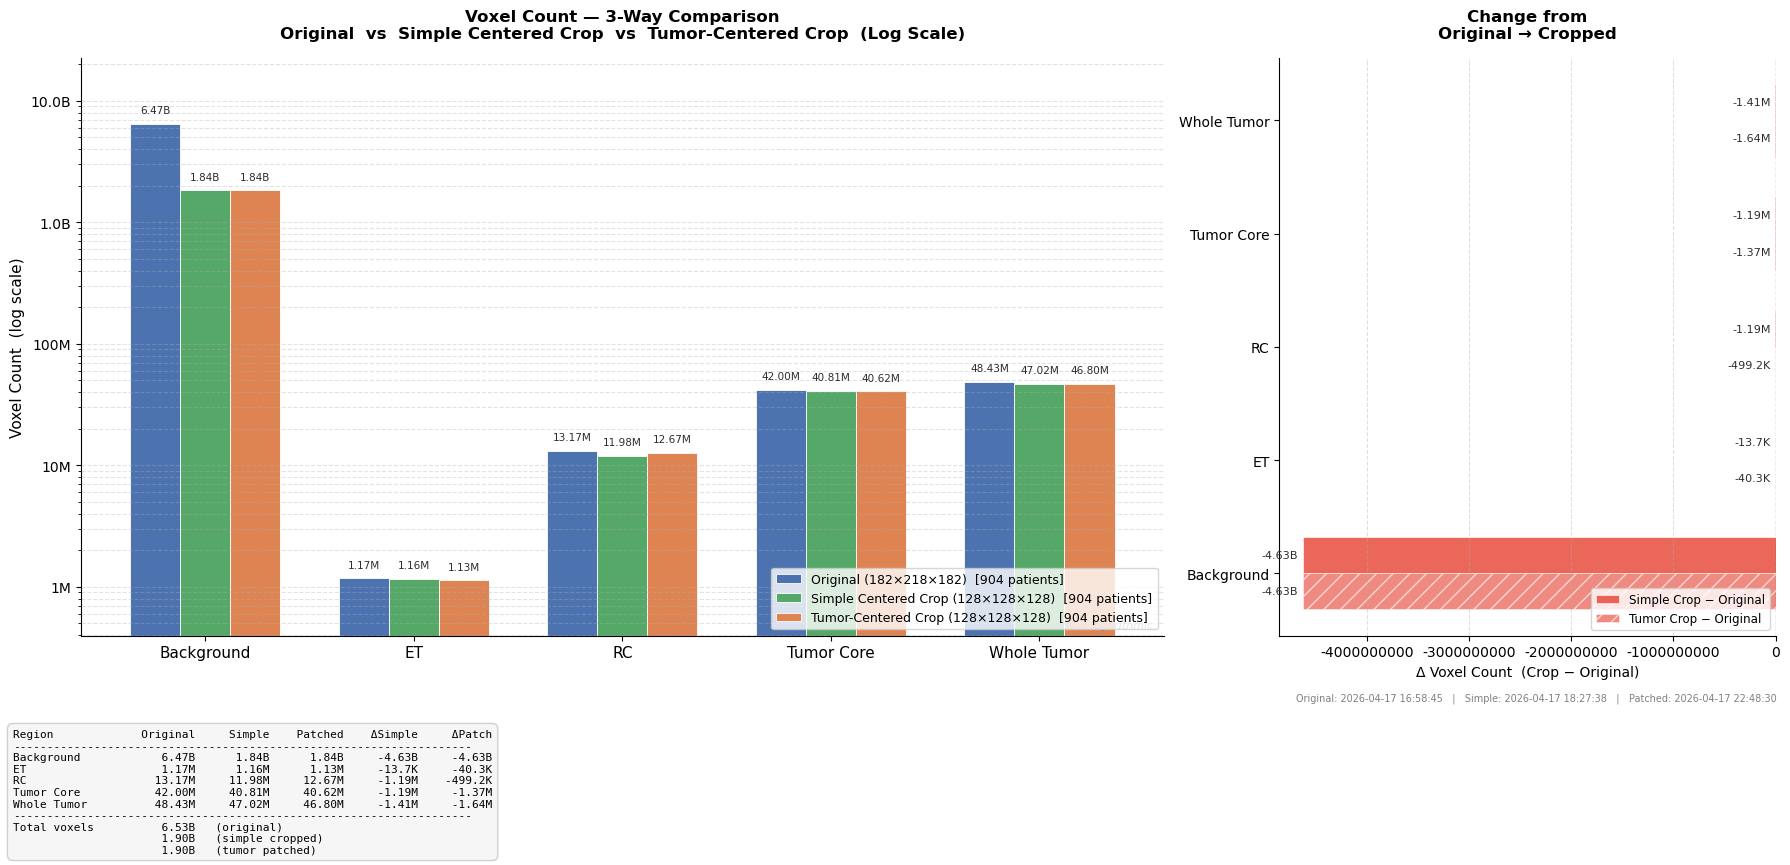


  Region             Original     Simple    Patched   ΔSimple    ΔPatch
  --------------------------------------------------------------------
  Background            6.47B      1.84B      1.84B  ▼    4.63B  ▼    4.63B
  ET                    1.17M      1.16M      1.13M  ▼    13.7K  ▼    40.3K
  RC                   13.17M     11.98M     12.67M  ▼    1.19M  ▼   499.2K
  Tumor Core           42.00M     40.81M     40.62M  ▼    1.19M  ▼    1.37M
  Whole Tumor          48.43M     47.02M     46.80M  ▼    1.41M  ▼    1.64M


In [12]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ============================================================
#  CONFIGURATION
# ============================================================
log_dir            = r"C:\Users\Wahaj Sajid\Desktop\Final-Year-Project\Code\Data Files Extraction\logs"
log_original       = os.path.join(log_dir, "log_original.json")
log_simple_cropped = os.path.join(log_dir, "log_simple_centered_patch.json")
log_patched        = os.path.join(log_dir, "log_tumor_centered_patch.json")
output_plot        = os.path.join(log_dir, "comparison_chart_3way.png")

COMPARE_REGIONS = ["Background", "ET", "RC", "Tumor Core", "Whole Tumor"]

RUN_CONFIGS = {
    "original"       : {"label": "Original (182×218×182)",             "color": "#4C72B0"},
    "simple_cropped" : {"label": "Simple Centered Crop (128×128×128)", "color": "#55A868"},
    "patched"        : {"label": "Tumor-Centered Crop (128×128×128)",  "color": "#DD8452"},
}
# ============================================================


# -------------------------------------------------------
# Helper — format a raw voxel count as e.g. "4.2M" or "1.1B"
# -------------------------------------------------------
def fmt_count(n):
    """Return a human-readable string: 1.23B, 456.7M, 12.3M, etc."""
    abs_n = abs(n)
    if abs_n >= 1_000_000_000:
        return f"{n / 1_000_000_000:.2f}B"
    elif abs_n >= 1_000_000:
        return f"{n / 1_000_000:.2f}M"
    elif abs_n >= 1_000:
        return f"{n / 1_000:.1f}K"
    else:
        return str(int(n))

def fmt_delta(n):
    """Same as fmt_count but always shows + or - sign."""
    abs_n = abs(n)
    sign  = "+" if n >= 0 else "-"
    if abs_n >= 1_000_000_000:
        return f"{sign}{abs_n / 1_000_000_000:.2f}B"
    elif abs_n >= 1_000_000:
        return f"{sign}{abs_n / 1_000_000:.2f}M"
    elif abs_n >= 1_000:
        return f"{sign}{abs_n / 1_000:.1f}K"
    else:
        return f"{sign}{int(abs_n)}"

# Y-axis tick formatter (same logic, no sign)
def ytick_fmt(val, _):
    if val >= 1_000_000_000:
        return f"{val / 1_000_000_000:.1f}B"
    elif val >= 1_000_000:
        return f"{val / 1_000_000:.0f}M"
    elif val >= 1_000:
        return f"{val / 1_000:.0f}K"
    return str(int(val))


# -------------------------------------------------------
# Load logs
# -------------------------------------------------------
def load_log(path, key):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Log file not found: {path}\n"
            f"Run voxel_counter.py with run_name = '{key}' first."
        )
    with open(path) as f:
        return json.load(f)


orig    = load_log(log_original,       "original")
simple  = load_log(log_simple_cropped, "simple_centered_patch")
patched = load_log(log_patched,        "tumor_centered_patch")

logs = {
    "original"       : orig,
    "simple_cropped" : simple,
    "patched"        : patched,
}

# -------------------------------------------------------
# Pull RAW COUNTS (not percentages) for each run & region
# -------------------------------------------------------
counts = {key: [logs[key]["region_counts"][r] for r in COMPARE_REGIONS]
          for key in RUN_CONFIGS}


# -------------------------------------------------------
# Layout
# -------------------------------------------------------
n_regions = len(COMPARE_REGIONS)
width     = 0.24
offsets   = [-width, 0, width]
x         = np.arange(n_regions)

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         gridspec_kw={"width_ratios": [2.4, 1.1]})

# ===========================
# LEFT — 3-bar grouped chart (LOG SCALE, raw counts)
# ===========================
ax = axes[0]

run_keys   = list(RUN_CONFIGS.keys())
bar_groups = {}

for i, key in enumerate(run_keys):
    cfg   = RUN_CONFIGS[key]
    vals  = counts[key]
    n_pts = logs[key]["num_patients"]
    bars  = ax.bar(
        x + offsets[i], vals, width,
        label=f"{cfg['label']}  [{n_pts} patients]",
        color=cfg["color"],
        edgecolor="white", linewidth=0.6
    )
    bar_groups[key] = bars

# Log scale
ax.set_yscale("log")

# Value labels above each bar
for key, bars in bar_groups.items():
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h * 1.18,
            fmt_count(h),
            ha="center", va="bottom",
            fontsize=7.5, color="#2c2c2c"
        )

# Y-axis: formatted ticks
ax.yaxis.set_major_formatter(mticker.FuncFormatter(ytick_fmt))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

all_vals = [v for c in counts.values() for v in c if v > 0]
ax.set_ylim(min(all_vals) * 0.35, max(all_vals) * 3.5)

ax.set_xticks(x)
ax.set_xticklabels(COMPARE_REGIONS, fontsize=11)
ax.set_ylabel("Voxel Count  (log scale)", fontsize=11)
ax.set_title(
    "Voxel Count — 3-Way Comparison\n"
    "Original  vs  Simple Centered Crop  vs  Tumor-Centered Crop  (Log Scale)",
    fontsize=12, fontweight="bold", pad=14
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", which="both", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0.99, 0.01, "Y-axis is logarithmic",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8, color="gray", style="italic")

# ===========================
# RIGHT — delta chart (absolute count difference vs original)
# ===========================
ax2 = axes[1]

delta_simple  = [s - o for s, o in zip(counts["simple_cropped"], counts["original"])]
delta_patched = [p - o for p, o in zip(counts["patched"],        counts["original"])]

bar_height = 0.32
y_base     = np.arange(n_regions, dtype=float)
y_simple   = y_base + bar_height / 2
y_patched  = y_base - bar_height / 2

def delta_color(v):
    return "#2ecc71" if v >= 0 else "#e74c3c"

bars_s = ax2.barh(y_simple, delta_simple,
                  height=bar_height,
                  color=[delta_color(d) for d in delta_simple],
                  edgecolor="white", linewidth=0.5,
                  label="Simple Crop − Original",
                  alpha=0.85)

bars_p = ax2.barh(y_patched, delta_patched,
                  height=bar_height,
                  color=[delta_color(d) for d in delta_patched],
                  edgecolor="white", linewidth=0.5,
                  label="Tumor Crop − Original",
                  alpha=0.65, hatch="//")

# Dynamic x-offset for labels (1% of max delta range)
max_delta = max(abs(d) for d in delta_simple + delta_patched)
x_pad     = max_delta * 0.01

def label_delta_bars(bars, deltas):
    for bar, d in zip(bars, deltas):
        xpos = d + (x_pad if d >= 0 else -x_pad)
        ha   = "left" if d >= 0 else "right"
        ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
                 fmt_delta(d), va="center", ha=ha,
                 fontsize=8, color="#2c2c2c")

label_delta_bars(bars_s, delta_simple)
label_delta_bars(bars_p, delta_patched)

ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_yticks(y_base)
ax2.set_yticklabels(COMPARE_REGIONS, fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(ytick_fmt))
ax2.set_xlabel("Δ Voxel Count  (Crop − Original)", fontsize=10)
ax2.set_title("Change from\nOriginal → Cropped", fontsize=12,
              fontweight="bold", pad=14)
ax2.legend(fontsize=8.5, loc="lower right")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)

# -------------------------------------------------------
# Summary text box
# -------------------------------------------------------
summary_lines = [
    f"{'Region':<16} {'Original':>10} {'Simple':>10} {'Patched':>10} {'ΔSimple':>10} {'ΔPatch':>10}",
    "-" * 68,
]
for r, o, s, p, ds, dp in zip(
    COMPARE_REGIONS,
    counts["original"], counts["simple_cropped"], counts["patched"],
    delta_simple, delta_patched
):
    summary_lines.append(
        f"{r:<16} {fmt_count(o):>10} {fmt_count(s):>10} {fmt_count(p):>10} "
        f"{fmt_delta(ds):>10} {fmt_delta(dp):>10}"
    )

summary_lines += [
    "-" * 68,
    f"{'Total voxels':<16} {fmt_count(orig['total_voxels']):>10}   (original)",
    f"{'':16} {fmt_count(simple['total_voxels']):>10}   (simple cropped)",
    f"{'':16} {fmt_count(patched['total_voxels']):>10}   (tumor patched)",
]

fig.text(0.01, -0.05, "\n".join(summary_lines),
         fontsize=8, family="monospace",
         verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5",
                   edgecolor="#cccccc", alpha=0.9))

# Metadata footer
fig.text(
    0.99, -0.01,
    f"Original: {orig['timestamp']}   |   "
    f"Simple: {simple['timestamp']}   |   "
    f"Patched: {patched['timestamp']}",
    ha="right", fontsize=7, color="gray"
)

plt.tight_layout()
plt.savefig(output_plot, dpi=150, bbox_inches="tight")
print(f"\n[INFO] Chart saved  →  {output_plot}")
plt.show()

# -------------------------------------------------------
# Console summary
# -------------------------------------------------------
print("\n" + "=" * 72)
print(f"  {'Region':<16} {'Original':>10} {'Simple':>10} {'Patched':>10} {'ΔSimple':>9} {'ΔPatch':>9}")
print("  " + "-" * 68)
for r, o, s, p, ds, dp in zip(
    COMPARE_REGIONS,
    counts["original"], counts["simple_cropped"], counts["patched"],
    delta_simple, delta_patched
):
    as_ = "▲" if ds > 0 else ("▼" if ds < 0 else "=")
    ap  = "▲" if dp > 0 else ("▼" if dp < 0 else "=")
    print(f"  {r:<16} {fmt_count(o):>10} {fmt_count(s):>10} {fmt_count(p):>10}  "
          f"{as_} {fmt_count(abs(ds)):>8}  {ap} {fmt_count(abs(dp)):>8}")
print("=" * 72)